In [38]:
%load_ext autoreload
%autoreload 2

import logging
import re
from pathlib import Path
from typing import Any

import geopandas as gpd
import joblib
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.figure import Figure
from matplotlib.patches import Patch

from ppcluster import load_config, setup_logger

%matplotlib widget

logger = setup_logger(logging.INFO, name="ppcx")

input_dir = Path("output/2019")
output_dir = input_dir / "kinematic_sectors_time_series"

config = load_config()

if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

output_dir.mkdir(parents=True, exist_ok=True)

UNIT = "px"
UNIT_SCALE = 1.0  # 1 for px, or the m/px conversion factor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
def find_result_folders(
    base_dir: Path, pattern: str = r".*_\d{4}-\d{2}-\d{2}$"
) -> list[Path]:
    """
    Find result folders matching `pattern` under `base_dir`.

    Args:
        base_dir: directory to scan for result folders
        pattern: regex to match folder names (default: CAMERA_YYYY-MM-DD)

    Returns:
        Sorted list of Path objects for folders that match the pattern.
    """
    folders = []
    date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

    for folder in base_dir.iterdir():
        if not folder.is_dir():
            continue
        if re.match(pattern, folder.name):
            # Extract date from folder name
            match = date_pattern.search(folder.name)
            if match:
                date_str = match.group(1)
                folders.append((date_str, folder))

    # Sort by date
    folders.sort(key=lambda x: x[0])

    # Return only folder paths
    folders = [folder for _, folder in folders]

    return folders


def load_sector_results(
    folder: Path, search_pattern: str | None = None
) -> dict[str, Any] | None:
    """
    Load a single date results bundle from `folder`.

    Args:
        folder: path to a results folder
        search_pattern: glob pattern to find the results bundle (default "*results.joblib")

    Returns:
        Dict with keys "date", "sectors", "stats", "pts_by_sector" on success, None on failure.
    """
    try:
        # Auto-detect base_name from folder if not provided
        if search_pattern is None:
            search_pattern = "*results.joblib"

        # Look for the bundle file
        bundle_files = list(folder.glob(search_pattern))
        if not bundle_files:
            raise FileNotFoundError(f"No bundle file found in {folder}")

        if len(bundle_files) > 1:
            logger.warning(
                f"Multiple bundle files found in {folder}, using the first one"
            )
        bundle_path = bundle_files[0]

        # Load main results bundle
        if not bundle_path.exists():
            raise FileNotFoundError(f"Bundle file not found: {bundle_path}")

        bundle = joblib.load(bundle_path)
        if not isinstance(bundle, dict):
            raise ValueError(f"Invalid bundle format in {bundle_path}")

        # Extract relevant data
        date = bundle.get("reference_date", None)
        sectors = bundle.get("sectors", None)
        pts_by_sector = bundle.get("pts_by_sector", None)

        return {
            "date": date,
            "sectors": sectors,
            "pts_by_sector": pts_by_sector,
        }

    except Exception as exc:
        logger.error(f"Failed to load results from {folder}: {exc}")
        return None


def collect_statistics(
    results_list: list[dict[str, Any] | None],
) -> pd.DataFrame:
    """
    Collect and reorganize time series statistics per sector into a single GeoDataFrame.
    """

    if not results_list:
        logger.warning("collect_statistics: empty results_list")
        return pd.DataFrame()

    frames = []
    for idx, result in enumerate(results_list):
        if not result:
            continue

        date_str = result.get("date")

        # Use the GeoDataFrame 'sectors' which contains stats + geometry
        gdf_sectors = result.get("sectors")

        try:
            date_ts = pd.to_datetime(date_str)
        except Exception:
            logger.error(f"Invalid date: {date_str}")
            continue

        # Work on a copy
        df_daily = gdf_sectors.copy()

        # Ensure 'sector' identifier column exists
        if "sector" not in df_daily.columns:
            raise KeyError("'sector' column not found in sectors GeoDataFrame")

        # Add date column
        df_daily["date"] = date_ts

        # Calculate spatial extents if geometry is available (for swimmer/centroid plots)
        if "geometry" in df_daily.columns:
            # Ensure valid geometries
            valid_geom = df_daily[
                df_daily.geometry.notna() & ~df_daily.geometry.is_empty
            ]
            if not valid_geom.empty:
                # Calculate centroid Y (elevation) and extents
                df_daily["centroid_y"] = df_daily.geometry.centroid.y
                df_daily["min_y"] = df_daily.geometry.bounds.miny
                df_daily["max_y"] = df_daily.geometry.bounds.maxy

        frames.append(df_daily)

    if not frames:
        logger.warning("collect_statistics: no valid frames collected")
        return pd.DataFrame()

    # Concatenate all daily frames
    # pd.concat handles GeoDataFrames correctly if they are uniform
    combined_df = pd.concat(frames, ignore_index=True)

    # Sort for time series plotting
    combined_df = combined_df.sort_values(by=["date", "sector"]).reset_index(drop=True)

    return combined_df


def collect_points_time_series(
    results_list: list[dict[str, Any] | None],
) -> pd.DataFrame:
    """
    Collect point-level data across all dates into a single time series DataFrame.

    Each row represents a single point at a specific date, with columns:
    - date: observation date
    - sector: sector label (A, B, C, D, etc.)
    - x, y: spatial coordinates
    - u, v: velocity components
    - V: velocity magnitude
    - geometry: point geometry
    - cluster_id: cluster membership ID
    - area: associated area

    Args:
        results_list: List of result dictionaries (one per date)

    Returns:
        DataFrame with all points from all dates concatenated and sorted
    """
    if not results_list:
        logger.warning("collect_points_time_series: empty results_list")
        return pd.DataFrame()

    frames = []

    for result in results_list:
        if not result:
            continue

        date_str = result.get("date")
        pts_by_sector = result.get("pts_by_sector")

        if pts_by_sector is None or pts_by_sector.empty:
            continue

        try:
            date_ts = pd.to_datetime(date_str)
        except Exception:
            logger.error(f"Invalid date: {date_str}")
            continue

        # Copy points DataFrame and add date column
        df_points = pts_by_sector.copy()
        df_points["date"] = date_ts

        frames.append(df_points)

    if not frames:
        logger.warning("collect_points_time_series: no valid frames collected")
        return pd.DataFrame()

    # Concatenate all daily point frames
    combined_pts = pd.concat(frames, ignore_index=True)

    # Sort by date and sector for organized output
    combined_pts = combined_pts.sort_values(by=["date", "sector"]).reset_index(
        drop=True
    )

    logger.info(
        f"Collected {len(combined_pts)} points across "
        f"{combined_pts['date'].nunique()} dates and "
        f"{combined_pts['sector'].nunique()} sectors"
    )

    return combined_pts


In [40]:
dir_pattern = r".*_\d{4}-\d{2}-\d{2}$"
results_pattern = "*results.joblib"

# Find result folders
logger.info(f"Searching for result folders in {input_dir}...")
folders = find_result_folders(input_dir, pattern=dir_pattern)
logger.info(f"Found {len(folders)} result folders")

# Load results from all dates
logger.info("Loading results from all dates...")
results_list = []
for folder in folders:
    result = load_sector_results(folder, search_pattern=results_pattern)
    if result is not None:
        results_list.append(result)

logger.info(f"Successfully loaded {len(results_list)} / {len(folders)} results")

2026-01-23 16:24:37 | [INFO    ] Searching for result folders in output/2019...
2026-01-23 16:24:37 | [INFO    ] Found 152 result folders
2026-01-23 16:24:37 | [INFO    ] Loading results from all dates...
2026-01-23 16:24:37 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-06-10: No bundle file found in output/2019/PPCX_Tele_2019-06-10
2026-01-23 16:24:37 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-06-11: No bundle file found in output/2019/PPCX_Tele_2019-06-11
2026-01-23 16:24:38 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-09-13: No bundle file found in output/2019/PPCX_Tele_2019-09-13
2026-01-23 16:24:38 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-09-21: No bundle file found in output/2019/PPCX_Tele_2019-09-21
2026-01-23 16:24:38 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-10-15: No bundle file found in output/2019/PPCX_Tele_2019-10-15
2026-01-23 16:24:38 | [ERROR   ] Fa

In [41]:
# Collect sector statistics into a DataFrame
df_sectors = collect_statistics(results_list)
logger.info(
    f"Successfully loaded {len(df_sectors)} records from {len(df_sectors['date'].unique())} dates"
)

# Collect point-level time series data
df_points_ts = collect_points_time_series(results_list)
columns_to_drop = ["geometry", "cluster_id", "area"]
df_points_ts = df_points_ts.drop(columns=columns_to_drop, errors="ignore")

logger.info(f"Points time series shape: {df_points_ts.shape}")
logger.info(f"Columns: {df_points_ts.columns.tolist()}")

2026-01-23 16:24:39 | [INFO    ] Successfully loaded 544 records from 136 dates
2026-01-23 16:24:39 | [INFO    ] Collected 295137 points across 136 dates and 4 sectors
2026-01-23 16:24:39 | [INFO    ] Points time series shape: (295137, 7)
2026-01-23 16:24:39 | [INFO    ] Columns: ['x', 'y', 'u', 'v', 'V', 'sector', 'date']


2026-01-23 16:24:53 | [INFO    ] Saved distribution evolution plot to output/2019/kinematic_sectors_time_series/sectors_velocity_boxplot_evolution.png


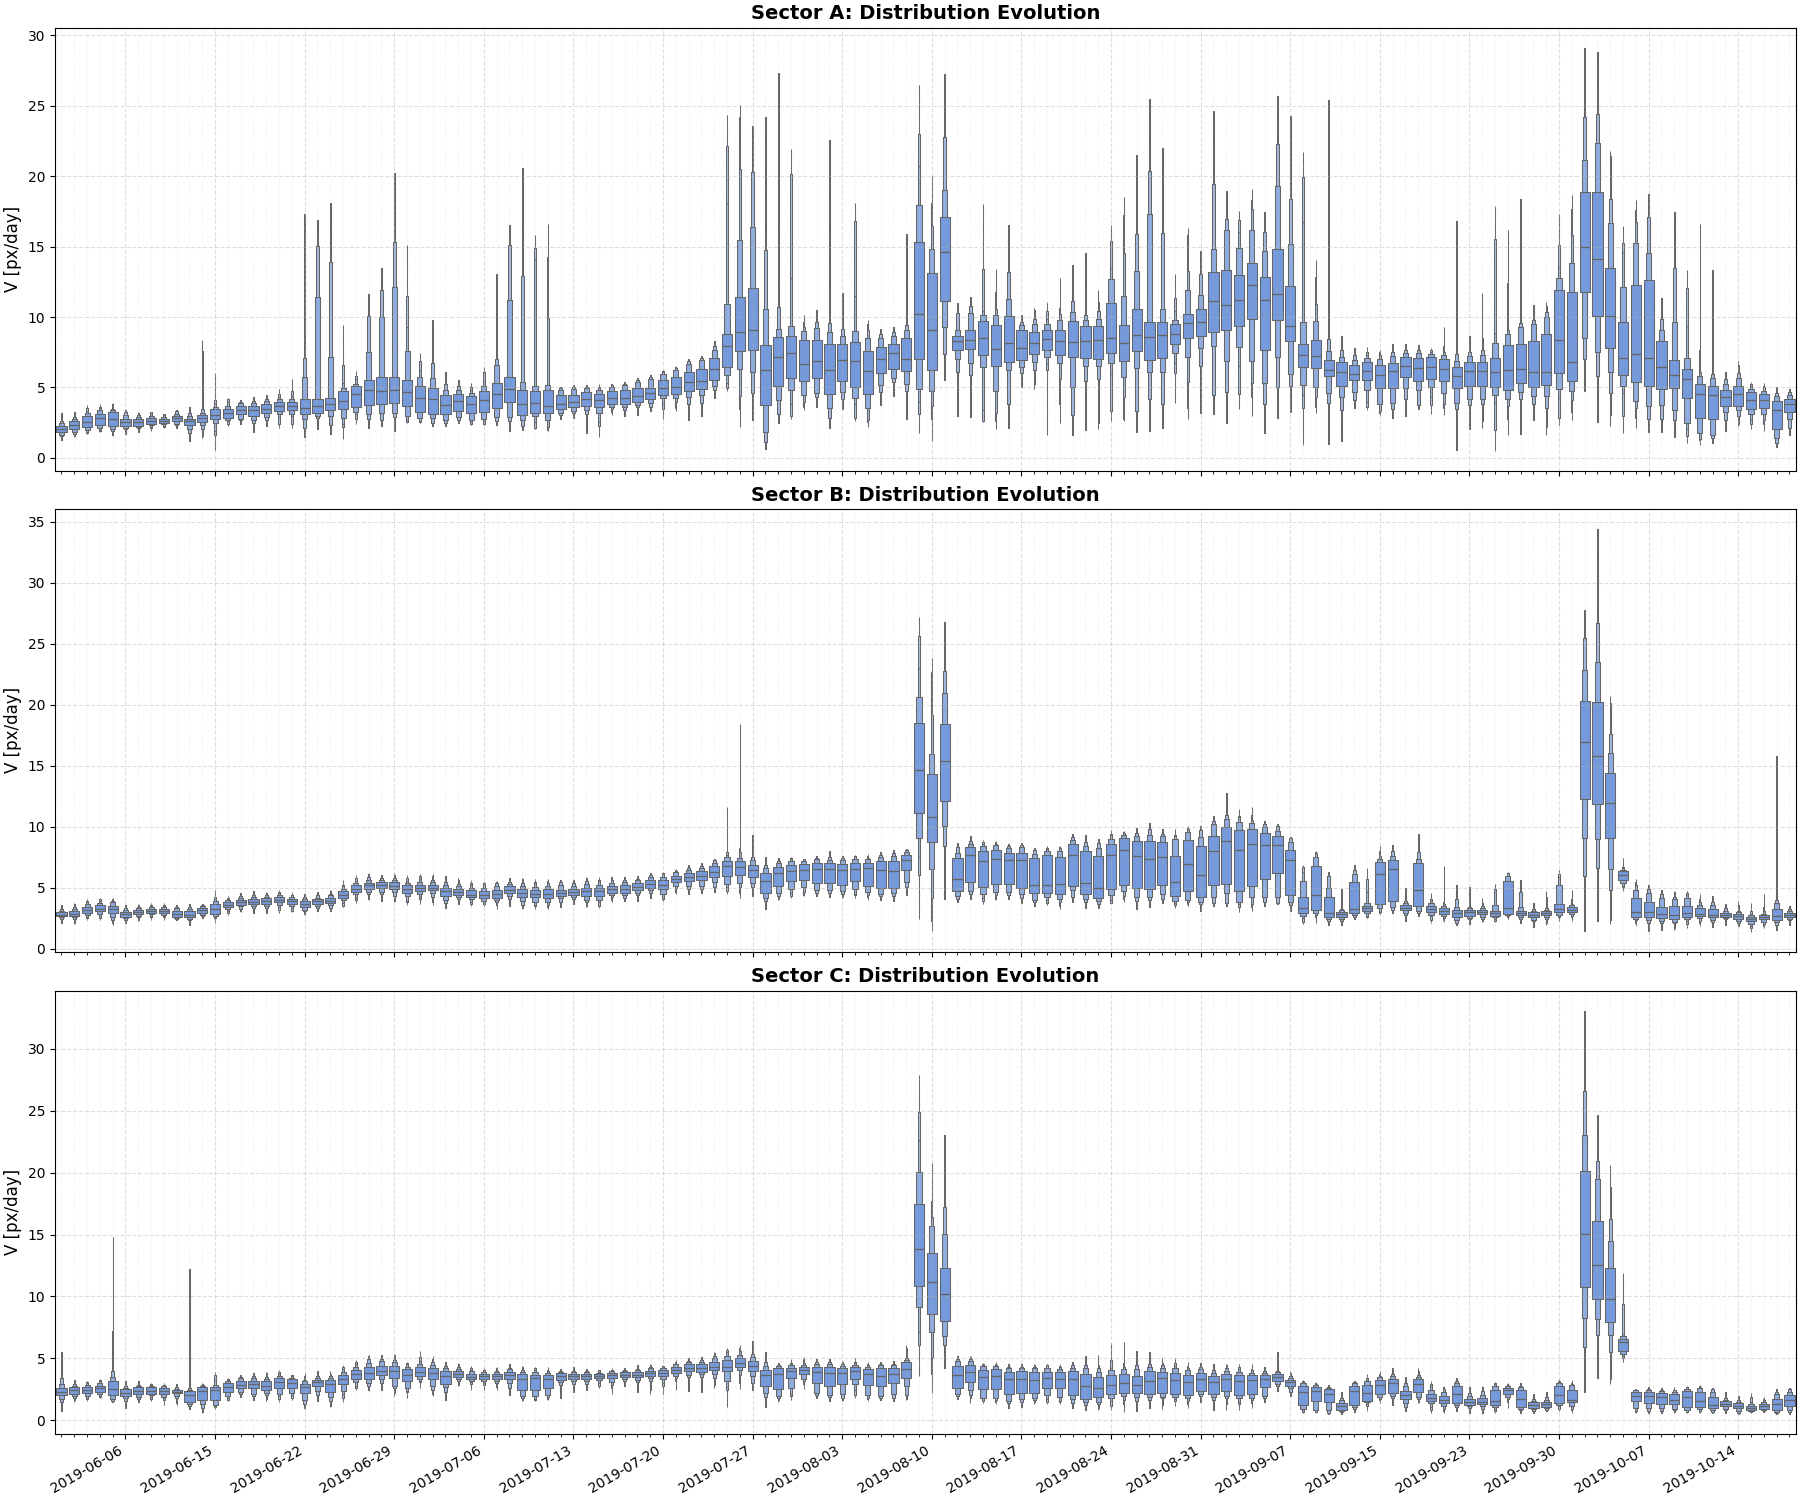

In [42]:
def plot_sector_evolution_boxplots(
    df: pd.DataFrame,
    col: str = "V",
    unit: str = "px",
    sectors: list[str] | None = None,
    output_path: Path | None = None,
) -> Figure:
    """
    Plots the time evolution of the distribution (boxenplot) of a specific variable for each sector.

    Args:
        df: Input dataframe containing time series point data. Must contain 'date', 'sector', and `col`.
        col: Column name to visualize (e.g., 'V').
        unit: Unit string for the y-axis label.
        sectors: List of sectors to include. If None, all sectors in df are used.
        output_path: Optional path to save the figure.

    Returns:
        The matplotlib Figure object.
    """
    df_viz = df.copy()

    # Default to all sectors if not provided
    if sectors is None:
        sectors = sorted(df_viz["sector"].unique())

    n_sectors = len(sectors)
    if n_sectors == 0:
        logger.warning("No sectors found to plot.")
        return plt.figure()

    # Sort for consistent plotting
    df_viz = df_viz.sort_values(["sector", "date"])

    # Create one wide subplot per sector
    fig, axes = plt.subplots(
        n_sectors, 1, figsize=(18, 5 * n_sectors), constrained_layout=True
    )
    # Ensure axes is iterable even if only 1 sector
    if n_sectors == 1:
        axes = [axes]

    for ax, sector in zip(axes, sectors, strict=False):
        subset = df_viz[df_viz["sector"] == sector]

        if subset.empty:
            ax.text(0.5, 0.5, "No Data", ha="center", va="center")
            continue

        # Boxenplot is optimal for large datasets (shows more quantiles than a boxplot)
        sns.boxenplot(
            data=subset,
            x="date",
            y=col,
            ax=ax,
            color="cornflowerblue",
            showfliers=False,
        )

        # X-Axis formatting
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        ax.xaxis.set_minor_locator(mdates.DayLocator())

        # Labels and Grid
        ax.set_title(
            f"Sector {sector}: Distribution Evolution", fontsize=14, weight="bold"
        )
        ax.set_ylabel(f"{col} [{unit}/day]", fontsize=12)
        ax.set_xlabel("")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        ax.grid(axis="x", which="minor", linestyle=":", alpha=0.2)

    # Format dates across all subplots
    fig.autofmt_xdate()

    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        logger.info(f"Saved distribution evolution plot to {output_path}")

    return fig


_ = plot_sector_evolution_boxplots(
    df_points_ts,
    col="V",
    unit=UNIT,
    sectors=["A", "B", "C"],
    output_path=output_dir / "sectors_velocity_boxplot_evolution.png",
)


In [43]:
def plot_single_date_sector_distributions(
    df: pd.DataFrame,
    date: pd.Timestamp | str,
    sectors: list[str] | None = None,
    col: str = "V",
    min_samples: int = 8,
    output_path: Path | None = None,
    show: bool = True,
) -> Figure:
    """
    Plot distributions (hist+KDE, QQ, boxplot) for specified sectors on a single date.

    Args:
        df: Point-level time series dataframe containing 'date' and 'sector' columns.
        date: Date to plot (pd.Timestamp or string parsable by pd.to_datetime).
        sectors: List of sectors to plot. If None, uses all sectors present on the date.
        col: Column to plot (default 'V').
        min_samples: Minimum number of samples to run the normality test (default 8).
        output_path: Optional path to save the figure.
        show: If True, calls plt.show().

    Returns:
        The matplotlib Figure object.
    """
    date_ts = pd.to_datetime(date)
    df_day = df[df["date"] == date_ts]
    if df_day.empty:
        logger.warning(f"No points for {date_ts.date()}")
    if sectors is None:
        sectors = sorted(df_day["sector"].unique())
    n = len(sectors)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.2 * max(1, n)), squeeze=False)
    axes = axes.reshape(n, 3)
    for i, sector in enumerate(sectors):
        df_sec = df_day[df_day["sector"] == sector][col].dropna()
        ax_hist, ax_qq, ax_box = axes[i]

        # Hist + KDE
        sns.histplot(df_sec, kde=True, ax=ax_hist, color="steelblue")
        ax_hist.set_title(f"Sector {sector} – {col}")

        # QQ plot
        if len(df_sec) > 0:
            stats.probplot(df_sec, dist="norm", plot=ax_qq)
        ax_qq.set_title("QQ plot")

        # Boxplot (IQR outliers)
        sns.boxplot(x=df_sec, ax=ax_box, color="lightcoral", fliersize=3)
        ax_box.set_title("Boxplot (IQR fence)")

        # Normality test (D’Agostino K^2)
        if len(df_sec) >= min_samples:
            try:
                k2, p = stats.normaltest(df_sec)
                ax_hist.text(
                    0.02,
                    0.95,
                    f"K² {k2:.2f}, p={p:.2}",
                    transform=ax_hist.transAxes,
                    va="top",
                    ha="left",
                    fontsize=9,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
                )
            except Exception:
                pass

    plt.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        logger.info(f"Saved single-date sector distributions to {output_path}")
    if show:
        plt.show()
    return fig


# date_sel = pd.to_datetime("2020-08-02")
# _ = plot_single_date_sector_distributions(
#     df_points_ts,
#     date_sel,
#     sectors=["A", "B", "C"],
#     col="V",
# )


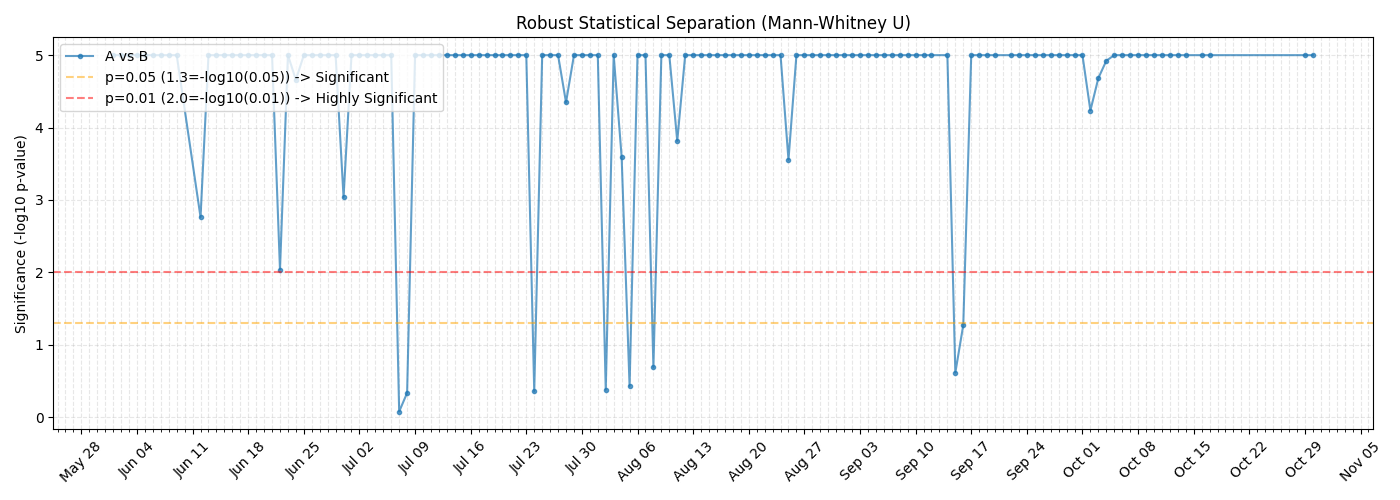

In [44]:
df_points = df_points_ts.copy()
sec1, sec2 = "A", "B"
rolling_days = None

# Group by date to perform the test daily
dates = sorted(df_points["date"].unique())
p_values = []
valid_dates = []
for date in dates:
    # Extract velocities for the specific day and sectors
    v1 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec1)][
        "V"
    ].dropna()
    v2 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec2)][
        "V"
    ].dropna()

    # Filter out outliers (>+-0.05 percentile)

    # Need minimal data points to run the test
    if len(v1) < 5 or len(v2) < 5:
        continue

    # Mann-Whitney U Test
    # alternative='two-sided' checks if distributions are different
    try:
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        p_values.append(p)
        valid_dates.append(date)
    except ValueError:
        continue

if not valid_dates:
    logger.warning(f"No valid data to test separation for {sec1} vs {sec2}")

# Convert to numpy array for processing
p_values = np.array(p_values)

# Avoid log(0)
p_values = np.where(p_values == 0, 1e-300, p_values)

label = f"{sec1} vs {sec2}"

# Plot -log10(p-value) for better visualization
# High value = High significance (Separated)
# Low value = Low significance (Merged/Same)
significance_score = -np.log10(p_values)

if rolling_days is not None:
    s_sig = pd.Series(significance_score, index=valid_dates)
    significance_score = (
        s_sig.rolling(window=f"{rolling_days}D", center=True).median().values
    )
    label += f" ({rolling_days}d median)"

fig, ax = plt.subplots(figsize=(14, 5))

# Cap the significance score for better visualization
significance_score_plt = np.clip(significance_score, 0, 5)

ax.plot(valid_dates, significance_score_plt, label=label, marker=".", alpha=0.7)

# Threshold lines
# p = 0.05 -> -log10(0.05) ~= 1.3
# p = 0.01 -> -log10(0.01) = 2.0
ax.axhline(
    1.3,
    color="orange",
    linestyle="--",
    alpha=0.5,
    label="p=0.05 (1.3=-log10(0.05)) -> Significant",
)
ax.axhline(
    2.0,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="p=0.01 (2.0=-log10(0.01)) -> Highly Significant",
)

ax.set_ylabel("Significance (-log10 p-value)")
ax.set_title("Robust Statistical Separation (Mann-Whitney U)")
ax.legend(loc="upper left")
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# x-axis formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


2026-01-23 16:25:15 | [INFO    ] Saved sector time series to output/2019/kinematic_sectors_time_series/sectors_time_series.png


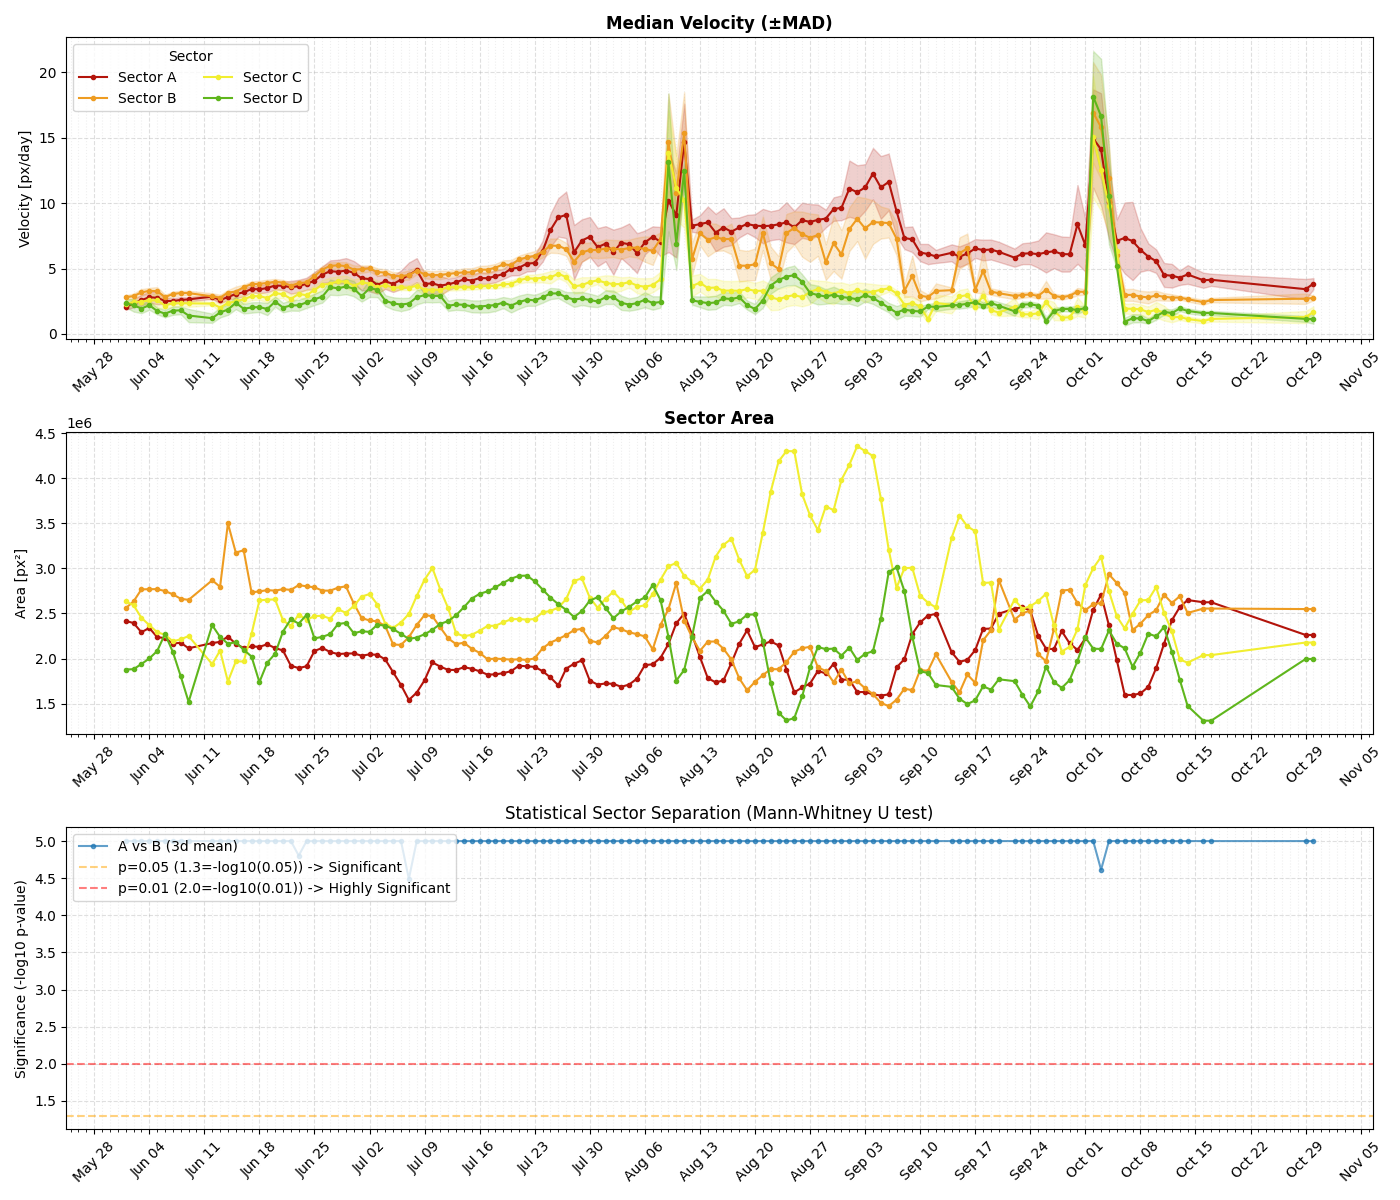

In [45]:
def plot_velocity_panel(ax, df_sectors, colors, unit: str = "px/day"):
    sectors = sorted(df_sectors["sector"].unique())
    for sector in sectors:
        subset = df_sectors[df_sectors["sector"] == sector]
        ax.plot(
            subset["date"],
            subset["v_median"],
            marker="o",
            markersize=3,
            label=f"Sector {sector}",
            color=colors.get(sector, "k"),
        )
        ax.fill_between(
            subset["date"],
            subset["v_median"] - subset["v_mad"],
            subset["v_median"] + subset["v_mad"],
            color=colors.get(sector, "k"),
            alpha=0.2,
        )
    ax.set_ylabel(f"Velocity [{unit}]")
    ax.set_title("Median Velocity (±MAD)", weight="bold")
    ax.legend(loc="upper left", title="Sector", ncol=2)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.tick_params(axis="x", labelrotation=45, labelbottom=True)

    return ax


def plot_area_panel(
    ax,
    df_sectors,
    colors,
    unit: str = "px²",
    rolling_days: int | None = None,
    rolling_function: str = "mean",
):
    sectors = sorted(df_sectors["sector"].unique())
    for sector in sectors:
        subset = df_sectors[df_sectors["sector"] == sector]

        area_values = subset["area_px2"]
        if rolling_days is not None:
            s = pd.Series(area_values.values, index=subset["date"])
            area_values = getattr(
                s.rolling(window=f"{rolling_days}D", center=True), rolling_function
            )().values
        ax.plot(
            subset["date"],
            area_values,
            marker="o",
            markersize=3,
            label=f"Sector {sector}",
            color=colors.get(sector, "k"),
        )
    ax.set_ylabel(f"Area [{unit}]")
    ax.set_title("Sector Area", weight="bold")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.tick_params(axis="x", labelrotation=45, labelbottom=True)

    return ax


def plot_velocity_separation_panel(
    ax,
    df_points: pd.DataFrame | gpd.GeoDataFrame,
    sector_pairs: list[tuple[str, str]],
    rolling_days: int | None = None,
    rolling_function: str = "mean",
    min_samples: int = 5,
    cap_significance: float = 5.0,
):
    """
    Plot statistical separation (Mann-Whitney U) between sector pairs over time.

    For each pair (sec1, sec2) the function:
      - groups point-level velocities by date,
      - runs Mann-Whitney U test when both sectors have at least `min_samples` points,
      - converts p-values to -log10(p) significance scores,
      - optionally applies a rolling function over `rolling_days`,
      - plots the (clipped) significance time series on `ax`.

    Args:
        ax: Matplotlib axis to draw on.
        df_points: Point DataFrame or GeoDataFrame with columns ['date', 'sector', 'V'].
        sector_pairs: Iterable of (sector1, sector2) tuples to compare.
        rolling_days: If provided, apply rolling function over this many days (e.g. 5).
        rolling_function: Rolling function to apply ('mean', 'median', etc.).
        min_samples: Minimum number of samples per sector/day to run the test.
        cap_significance: Maximum value to display for -log10(p) (controls clipping).

    Returns:
        The Matplotlib axis with the plotted separation panel.
    """
    # Ensure dates are sorted
    df_points = df_points.copy()
    all_dates = sorted(df_points["date"].unique())

    any_plotted = False
    for sec1, sec2 in sector_pairs:
        p_values = []
        valid_dates = []

        for date in all_dates:
            v1 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec1)][
                "V"
            ].dropna()
            v2 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec2)][
                "V"
            ].dropna()

            if len(v1) < min_samples or len(v2) < min_samples:
                continue

            try:
                _, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
                p_values.append(p)
                valid_dates.append(date)
            except ValueError:
                continue
            except Exception:
                continue

        if not valid_dates:
            logger.warning(f"No valid data to test separation for {sec1} vs {sec2}")
            continue

        any_plotted = True

        p_arr = np.array(p_values)
        p_arr = np.where(p_arr == 0, 1e-300, p_arr)  # avoid log(0)
        sig = -np.log10(p_arr)

        # Optional rolling median smoothing over calendar days
        if rolling_days is not None:
            s = pd.Series(sig, index=pd.DatetimeIndex(valid_dates))
            sig = getattr(
                s.rolling(window=f"{rolling_days}D", center=True), rolling_function
            )().values

        label = f"{sec1} vs {sec2}"
        if rolling_days is not None:
            label += f" ({rolling_days}d {rolling_function})"

        sig_plot = np.clip(sig, 0.0, cap_significance)
        ax.plot(valid_dates, sig_plot, label=label, marker=".", alpha=0.7)

    # Draw significance threshold lines and format axis
    # p = 0.05 -> -log10(0.05) ~= 1.3
    # p = 0.01 -> -log10(0.01) = 2.0
    ax.axhline(
        1.3,
        color="orange",
        linestyle="--",
        alpha=0.5,
        label="p=0.05 (1.3=-log10(0.05)) -> Significant",
    )
    ax.axhline(
        2.0,
        color="red",
        linestyle="--",
        alpha=0.5,
        label="p=0.01 (2.0=-log10(0.01)) -> Highly Significant",
    )

    ax.set_ylabel("Significance (-log10 p-value)")
    ax.set_title("Statistical Sector Separation (Mann-Whitney U test)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    # Date axis formatting
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.tick_params(axis="x", labelrotation=45, labelbottom=True)

    if any_plotted:
        ax.legend(loc="upper left")
    else:
        # still add the threshold legend entry to clarify the chart
        ax.legend(loc="upper left")

    return ax


# Figure with time series of velocity and area of each sector
output_path = output_dir / "sectors_time_series.png"
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

sectors = sorted(df_sectors["sector"].unique())
colors = config.postprocessing.sector_assignment.get("sector_colors", {})
if not colors:
    cmap = plt.get_cmap("tab10")
    colors = {s: cmap(i % cmap.N) for i, s in enumerate(sectors)}

ax1, ax2, ax3 = axes
plot_velocity_panel(
    ax1,
    df_sectors,
    colors,
    unit=f"{UNIT}/day",
)
plot_area_panel(
    ax2,
    df_sectors,
    colors,
    unit=f"{UNIT}²",
    rolling_days=3,
    rolling_function="mean",
)
plot_velocity_separation_panel(
    ax3,
    df_points=df_points_ts,
    sector_pairs=[("A", "B")],
    rolling_days=3,
    rolling_function="mean",
)
plt.tight_layout()
fig.savefig(output_path, dpi=300)
fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")
logger.info(f"Saved sector time series to {output_path}")

2026-01-23 16:25:18 | [INFO    ] Using fixed area bin size 1000000: bins [1000000. 2000000. 3000000. 4000000. 5000000.]


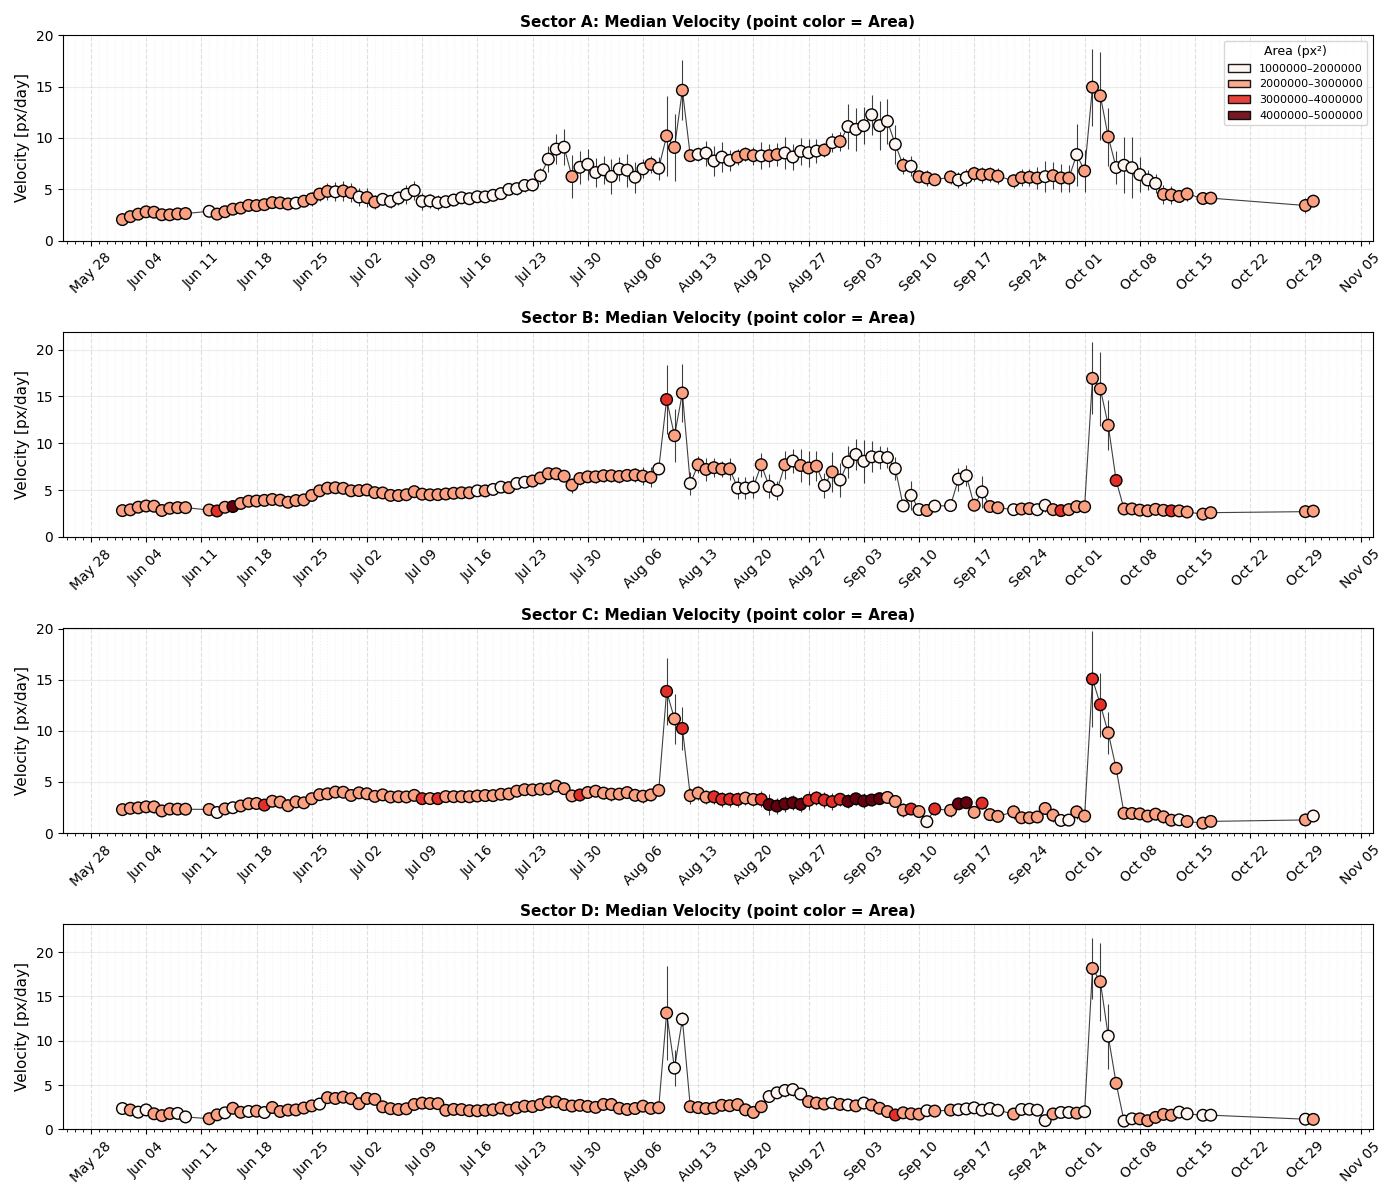

In [46]:
def plot_sectors_velocity_area_time_series(
    df_sectors: pd.DataFrame,
    output_path: Path,
    area_bin_size: int | None = 1_000_000,
    area_bin_edges: list[float] | None = None,
    fallback_n_bins: int = 5,
    max_panels: int = 4,
    unit: str = UNIT,
    save_svg: bool = True,
) -> Figure:
    """
    Plot median velocity time series for each sector (one panel per sector),
    with point color indicating sector area bins.

    Returns the created matplotlib Figure.
    """
    if df_sectors.empty or "sector" not in df_sectors.columns:
        logger.warning("No sector data available for plotting")
        return plt.figure()

    # compute global area range (ignore NaNs) using the DataFrame column
    if "area_px2" not in df_sectors.columns:
        all_areas = np.array([])
    else:
        all_areas = df_sectors["area_px2"].dropna().values.astype(float)

    if all_areas.size == 0:
        min_a, max_a = 0.0, 1.0
    else:
        min_a, max_a = float(np.min(all_areas)), float(np.max(all_areas))
        if np.isclose(min_a, max_a):
            max_a = min_a + 1.0

    # Decide bins
    if area_bin_edges is not None:
        bins = np.asarray(area_bin_edges, dtype=float)
        logger.info(f"Using user-provided area bin edges: {bins}")
    elif area_bin_size:
        start = np.floor(min_a / area_bin_size) * area_bin_size
        stop = np.ceil(max_a / area_bin_size) * area_bin_size
        if start == stop:
            stop = start + area_bin_size
        bins = np.arange(start, stop + area_bin_size, area_bin_size)
        logger.info(f"Using fixed area bin size {area_bin_size}: bins {bins}")
    else:
        bins = np.linspace(min_a, max_a, fallback_n_bins + 1)
        logger.info(f"Using fallback linear bins (n={fallback_n_bins}): {bins}")

    n_bins = max(1, len(bins) - 1)
    cmap = plt.get_cmap("Reds", n_bins)
    colors_list = [cmap(i) for i in range(n_bins)]

    # Get unique sectors and limit panels
    sectors = sorted(df_sectors["sector"].unique())
    n_sectors = len(sectors)
    n_panels = min(max_panels, n_sectors)

    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3 * n_panels), squeeze=False)
    axes = axes.flatten()

    # create legend patches for area bins (one-time)
    area_patches = []
    for i in range(n_bins):
        low, high = bins[i], bins[i + 1]
        label = f"{low:.0f}–{high:.0f}"
        area_patches.append(
            Patch(facecolor=colors_list[i], edgecolor="k", label=label, alpha=0.9)
        )

    for ax, sector in zip(axes, sectors[:n_panels], strict=False):
        subset = df_sectors[df_sectors["sector"] == sector].sort_values("date")

        dates_dt = subset["date"]
        v_median = subset["v_median"].to_numpy(dtype=float)
        v_mad = subset["v_mad"].to_numpy(dtype=float)
        area = subset.get("area_px2", pd.Series(np.nan, index=subset.index)).to_numpy(
            dtype=float
        )

        # bin areas into discrete colors using numpy.digitize
        safe_area = np.nan_to_num(area, nan=bins[0])
        bin_idx = np.digitize(safe_area, bins) - 1  # index in 0..n_bins-1
        bin_idx = np.clip(bin_idx, 0, n_bins - 1)
        colors_area = [colors_list[i] for i in bin_idx]

        ax.errorbar(
            dates_dt,
            v_median,
            yerr=v_mad,
            markersize=0,
            linestyle="-",
            linewidth=0.8,
            label=f"Sector {sector}",
            color="k",
            alpha=0.75,
        )
        ax.scatter(
            dates_dt,
            v_median,
            s=70,
            c=colors_area,
            edgecolors="k",
            zorder=3,
        )

        ax.set_ylabel(f"Velocity [{unit}/day]", fontsize=11)
        ax.set_title(
            f"Sector {sector}: Median Velocity (point color = Area)",
            fontsize=11,
            weight="bold",
        )
        ax.grid(axis="y", alpha=0.25)

        # x-axis formatting
        major_locator = mdates.WeekdayLocator(interval=1)
        major_formatter = mdates.DateFormatter("%b %d")
        ax.xaxis.set_major_locator(major_locator)
        ax.xaxis.set_major_formatter(major_formatter)
        ax.xaxis.set_minor_locator(mdates.DayLocator())
        ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
        ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)

        ax.tick_params(axis="x", rotation=45, labelbottom=True)

        # Optional: consistent y-limits for better comparison
        if len(v_median) > 0:
            ax.set_ylim([0, max(20, np.nanmax(v_median) + 5)])  # simple fallback

    # place area color legend in the first axis (clear and compact)
    if axes.size > 0:
        axes[0].legend(
            handles=area_patches,
            title=f"Area ({unit}²)",
            loc="best",
            fontsize=8,
            title_fontsize=9,
        )

    fig.tight_layout()

    # Save
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    if save_svg:
        fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")

    return fig


# Replace inline block with a single function call
output_path = output_dir / "sectors_velocity_area_time_series.png"
fig = plot_sectors_velocity_area_time_series(df_sectors, output_path)

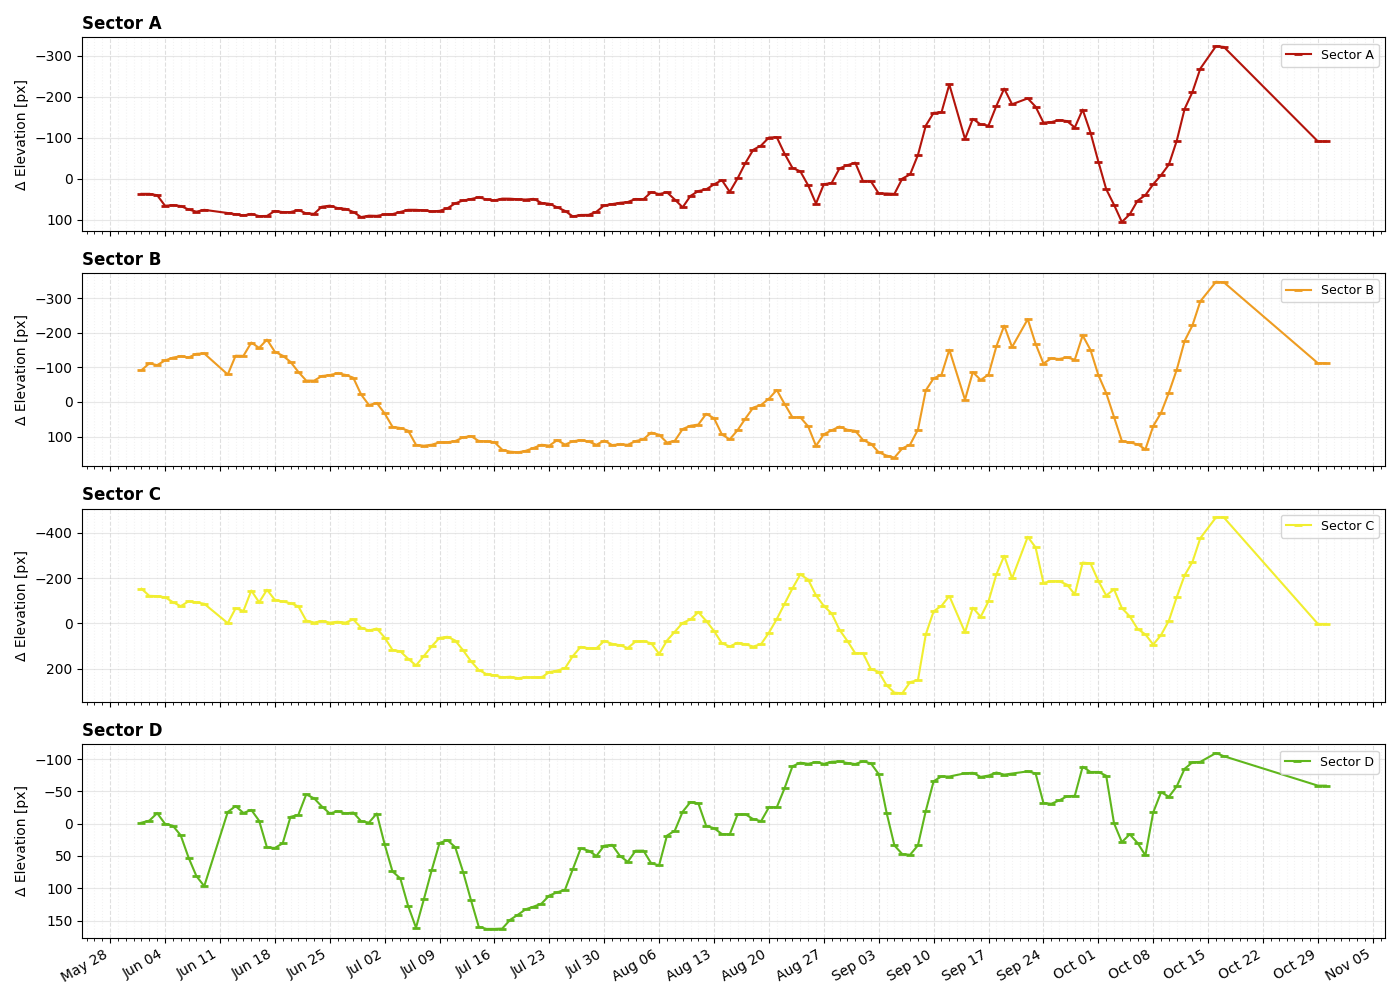

In [47]:
# Swimmer plot: vertical movement of sectors' centroid over time
def plot_swimmer_single_sector(
    ax,
    df_sector: pd.DataFrame,
    sector_label: str,
    color: str,
    plot_sector_extent: bool = True,
    subtract_mean: bool = True,
):
    """
    Plot the vertical movement (centroid & extent) for a single sector.

    Args:
        ax: Matplotlib axis to draw on
        df_sector: DataFrame containing data for ONE sector only (already filtered)
        sector_label: Label/name of the sector (for legend)
        color: Color to use for this sector
        subtract_mean: If True, plot relative to mean elevation (highlights movement)

    Returns:
        ax: The modified axis
    """
    # Check for required columns
    if "centroid_y" not in df_sector.columns:
        ax.text(
            0.5,
            0.5,
            "No spatial geometry data available",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return ax

    # Filter and sort
    subset = (
        df_sector.dropna(subset=["centroid_y", "min_y", "max_y"])
        .sort_values("date")
        .copy()
    )

    if subset.empty:
        ax.text(
            0.5,
            0.5,
            f"No valid data for Sector {sector_label}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return ax

    # Optionally subtract mean to show relative movement
    if subtract_mean:
        mean_y = subset["centroid_y"].mean()
        subset["centroid_y"] = subset["centroid_y"] - mean_y
        subset["min_y"] = subset["min_y"] - mean_y
        subset["max_y"] = subset["max_y"] - mean_y

    # Plot vertical extent (range bars)
    if plot_sector_extent:
        ax.vlines(
            subset["date"],
            subset["min_y"],
            subset["max_y"],
            color=color,
            alpha=0.2,
            linewidth=2,
            label=f"Sector {sector_label} Extent" if sector_label else None,
        )

    # Plot centroid trajectory
    ax.plot(
        subset["date"],
        subset["centroid_y"],
        marker="_",
        markersize=6,
        mew=2,
        linestyle="-",
        linewidth=1.5,
        color=color,
        label=f"Sector {sector_label}",
    )

    return ax


def plot_swimmer_all_sectors(
    df_sectors: pd.DataFrame,
    colors: dict,
    plot_sector_extent: bool = True,
    subtract_mean: bool = True,
    rolling_days: int | None = None,
):
    """
    Create swimmer plot(s) for all sectors.

    Args:
        df_sectors: Full DataFrame with all sectors and dates
        colors: Dict mapping sector labels to colors
        plot_sector_extent: If True, plot vertical extent bars for each sector
        subtract_mean: If True, center each sector around its mean elevation
        rolling_days: If provided, apply rolling mean smoothing over this many days

    Returns:
        fig: The matplotlib figure
    """
    sectors = sorted(df_sectors["sector"].unique())
    n_sectors = len(sectors)

    if n_sectors == 0:
        return None

    # Create figure layout
    fig, axes = plt.subplots(
        nrows=n_sectors, ncols=1, figsize=(14, 10), sharex=True, squeeze=False
    )
    axes_flat = axes.flatten()

    # Plot each sector
    for idx, sector in enumerate(sectors):
        ax = axes_flat[idx]
        df_sector = df_sectors[df_sectors["sector"] == sector]
        color = colors.get(sector, "k")

        # Apply rolling mean smoothing to centroid and extent columns
        if rolling_days is not None:
            df_sector = df_sector.sort_values("date").copy()
            for col in ["centroid_y", "min_y", "max_y"]:
                s_col = pd.Series(df_sector[col].values, index=df_sector["date"])
                df_sector[col] = (
                    s_col.rolling(window=f"{rolling_days}D", center=True).mean().values
                )

        plot_swimmer_single_sector(
            ax,
            df_sector,
            sector_label=sector,
            color=color,
            plot_sector_extent=plot_sector_extent,
            subtract_mean=subtract_mean,
        )

        # Styling for individual panels
        y_label = "Δ Elevation [px]" if subtract_mean else "Elevation [px]"
        ax.set_ylabel(y_label)
        ax.set_title(f"Sector {sector}", weight="bold", loc="left")
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=9)

        major_locator = mdates.WeekdayLocator(interval=1)
        major_formatter = mdates.DateFormatter("%b %d")
        ax.xaxis.set_major_locator(major_locator)
        ax.xaxis.set_major_formatter(major_formatter)
        ax.xaxis.set_minor_locator(mdates.DayLocator())
        ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
        ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)

    fig.autofmt_xdate()
    plt.tight_layout()

    return fig


# Separate panels (one row per sector)
fig_separate = plot_swimmer_all_sectors(
    df_sectors,
    colors,
    plot_sector_extent=False,
    subtract_mean=True,
    rolling_days=5,
)
fig_separate.savefig(output_dir / "sectors_centroid_location.png", dpi=300)

In [48]:
from typing import Any, Literal

from joblib import Parallel, delayed
from tqdm import tqdm

from ppcluster.sectors import plot_sectors


def create_sectors_evolution_mosaic(
    df_sectors: pd.DataFrame,
    output_base_path: Path,
    df_points: pd.DataFrame | None = None,
    image: Any = None,
    max_dates_per_figure: int = 24,
    ncols: int = 6,
    nrows: int | None = None,
    velocity_mode: Literal["quiver", "scatter"] = "scatter",
    velocity_cmap: str = "viridis",
    min_cbar: float | None = None,
    max_cbar: float | None = None,
    img_kwargs: dict | None = None,
    quiver_kwargs: dict | None = None,
    scatter_kwargs: dict | None = None,
    sector_kwargs: dict | None = None,
    sector_fill_kwargs: dict | None = None,
    sector_edge_kwargs: dict | None = None,
    save_svg: bool = False,
    n_jobs: int = 1,
):
    def _render_mosaic_chunk(part_idx: int, date_chunk):
        n_dates = len(date_chunk)
        rows = nrows if nrows else int(np.ceil(n_dates / ncols))

        fig, axes = plt.subplots(rows, ncols, figsize=(4 * ncols, 4 * rows))
        axes_flat = axes.flatten()

        for idx, date in enumerate(date_chunk):
            ax = axes_flat[idx]
            daily_gdf = gpd.GeoDataFrame(df_sectors[df_sectors["date"] == date])
            if daily_gdf.empty:
                ax.axis("off")
                continue

            if df_points is not None:
                daily_pts = df_points[df_points["date"] == date]
            else:
                daily_pts = None

            plot_sectors(
                ax=ax,
                sectors=daily_gdf,
                img=image,
                velocity_df=daily_pts,
                velocity_mode=velocity_mode,
                velocity_cmap=velocity_cmap,
                min_cbar=min_cbar,
                max_cbar=max_cbar,
                sector_colors=sectors_colors,
                add_sector_labels=False,
                title=date.strftime("%Y-%m-%d"),
                img_kwargs=img_kwargs,
                quiver_kwargs=quiver_kwargs,
                scatter_kwargs=scatter_kwargs,
                sector_kwargs=sector_kwargs,
                sector_fill_kwargs=sector_fill_kwargs,
                sector_edge_kwargs=sector_edge_kwargs,
            )

            # Remove individual legends and labels for mosaic clarity
            legend = ax.get_legend()
            if legend:
                legend.remove()
            ax.set_xlabel("")
            ax.set_ylabel("")

            # If no image is passed, force inverting y-axis for image coordinate system
            if image is None:
                ax.invert_yaxis()
                ax.axis("equal")

        # Move a single legend outside the figure (right side)
        try:
            # create legend handles from the provided colors dict (sorted for consistency)
            if not sectors_colors:
                raise ValueError("No sector colors available for legend creation")
            legend_patches = [
                Patch(facecolor=sectors_colors[s], edgecolor="k", label=f"Sector {s}")
                for s in sorted(sectors_colors.keys())
            ]
            # leave room for the legend on the right
            fig.subplots_adjust(right=0.82)
            fig.legend(
                handles=legend_patches,
                title="Sector",
                loc="center left",
                bbox_to_anchor=(0.86, 0.5),
                frameon=False,
                fontsize=9,
                title_fontsize=10,
            )
        except Exception:
            logger.exception("Failed to create external legend for mosaic chunk")

        plt.suptitle(
            f"Sectors Geometric Evolution (Part {part_idx})",
            fontsize=20,
            weight="bold",
            y=0.92,
        )

        suffix = f"_part{part_idx}" if len(date_chunk) else ""
        out_path = output_base_path.with_name(f"{output_base_path.stem}{suffix}.jpg")
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        if save_svg:
            fig.savefig(out_path.with_suffix(".svg"), bbox_inches="tight")

        plt.close(fig)
        logger.debug(f"Saved mosaic: {out_path}")

    unique_dates = sorted(df_sectors["date"].unique())
    n_total_dates = len(unique_dates)

    sectors_list = sorted(df_sectors["sector"].unique())
    try:
        sectors_colors = config.postprocessing.sector_assignment.get(
            "sector_colors", {}
        )
    except Exception:
        logger.warning("Unable to get sector colors from config file")
        sectors_colors = None
    if not sectors_colors:
        cmap = plt.get_cmap("tab10")
        sectors_colors = {s: cmap(i % cmap.N) for i, s in enumerate(sectors_list)}

    # Creating chunks
    chunks = [
        unique_dates[i : i + max_dates_per_figure]
        for i in range(0, n_total_dates, max_dates_per_figure)
    ]
    logger.info(f"Created {len(chunks)} chunks for mosaic plotting")

    logger.info("Starting plotting of mosaic chunks... ")
    if n_jobs == 1:
        # Single-threaded execution for debugging
        for part_idx, date_chunk in tqdm(
            enumerate(chunks, 1),
            desc="Creating mosaic chunks",
            total=len(chunks),
            position=0,
        ):
            _render_mosaic_chunk(part_idx, date_chunk)
    else:
        # Multiprocessing execution
        Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(_render_mosaic_chunk)(part_idx, date_chunk)
            for part_idx, date_chunk in tqdm(
                enumerate(chunks, 1),
                desc="Creating mosaic chunks",
                total=len(chunks),
                position=0,
            )
        )
    logger.info("Completed mosaic plotting.")


# Generate mosaic for all available data
output_path_mosaic = output_dir / "sectors_evolution_mosaic"
plt.close("all")  # close any existing figures
create_sectors_evolution_mosaic(
    df_sectors,
    output_path_mosaic,
    image=None,
    df_points=df_points_ts,
    max_dates_per_figure=30,
    ncols=6,
    nrows=None,
    velocity_mode="scatter",
    velocity_cmap="Blues",
    min_cbar=0.0,
    max_cbar=10.0,
    img_kwargs=None,
    quiver_kwargs=None,
    scatter_kwargs={"s": 10, "alpha": 0.6},
    sector_kwargs=None,
    sector_fill_kwargs={"alpha": 0},
    sector_edge_kwargs={"linewidth": 5.0},
    save_svg=False,
    n_jobs=1,
)

2026-01-23 16:25:32 | [INFO    ] Created 5 chunks for mosaic plotting
2026-01-23 16:25:32 | [INFO    ] Starting plotting of mosaic chunks... 
Creating mosaic chunks:   0%|          | 0/5 [00:00<?, ?it/s]

Creating mosaic chunks: 100%|██████████| 5/5 [00:16<00:00,  3.26s/it]
2026-01-23 16:25:48 | [INFO    ] Completed mosaic plotting.
